# OpenAI Image Creation Demo

Using OpenAI's image generation capabilities.

## Install Dependencies

We need the OpenAI SDK and matplotlib for visualization.

In [1]:
!pip install openai pillow plotly python-dotenv -q

## Import Libraries

In [2]:
import os
import base64
from openai import OpenAI
from io import BytesIO
from dotenv import load_dotenv
from PIL import Image, ImageDraw, ImageFont

## Set AI Settings and Load Enviornment Key
Configure the OpenAI image model, specify the output location, and load the secure API key from `utils/.env`. Make sure the OpenAI key is added there.

In [ ]:
OPENAI_MODEL = "gpt-5"
OUTPUT_DIR = "output/openai"
os.makedirs(OUTPUT_DIR)

load_dotenv(dotenv_path="utils/.env")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

## Setup OpenAI Client

Set your API key as an environment variable.

In [4]:
client = OpenAI(api_key=OPENAI_API_KEY)

## Create a Prompt for Image Generation
Form a descriptive prompt of the image desired. Image formating parameters are set, but can be altered.

In [ ]:
FOCUS = "Dalmation pup"
IMAGE_FORMAT = "PNG"
IMAGE_STYLE = "realistic"

PROMPT = f"""
Generate a {IMAGE_STYLE} image of a {FOCUS} at a table having a birthday party with its canine friends. 
The image should be high to medium quality. 
The image should be in {IMAGE_FORMAT} format.
"""

## Generate Image

This function sends a prompt to OpenAI to create an image, then saves the generated image.

In [ ]:
def openai_generate_image():
    filename = f"{FOCUS}_{IMAGE_STYLE}.{IMAGE_FORMAT.lower()}"
    img_path = os.path.join(OUTPUT_DIR, filename)

    response = client.responses.create(
    model="gpt-5",
    input=PROMPT,
    tools=[{"type": "image_generation"}],
    )

    image_data = [
        output.result
        for output in response.output
        if output.type == "image_generation_call"
    ]
        
    if image_data:
        image_base64 = image_data[0]
        with open(img_path, "wb") as f:
            f.write(base64.b64decode(image_base64))
    
    return img_path

## Run Generation

Run the image generation function.

In [ ]:
print("Running picture generation...")
img_path = openai_generate_image()

Running picture generation...


## Display Image

Shows the generated image.

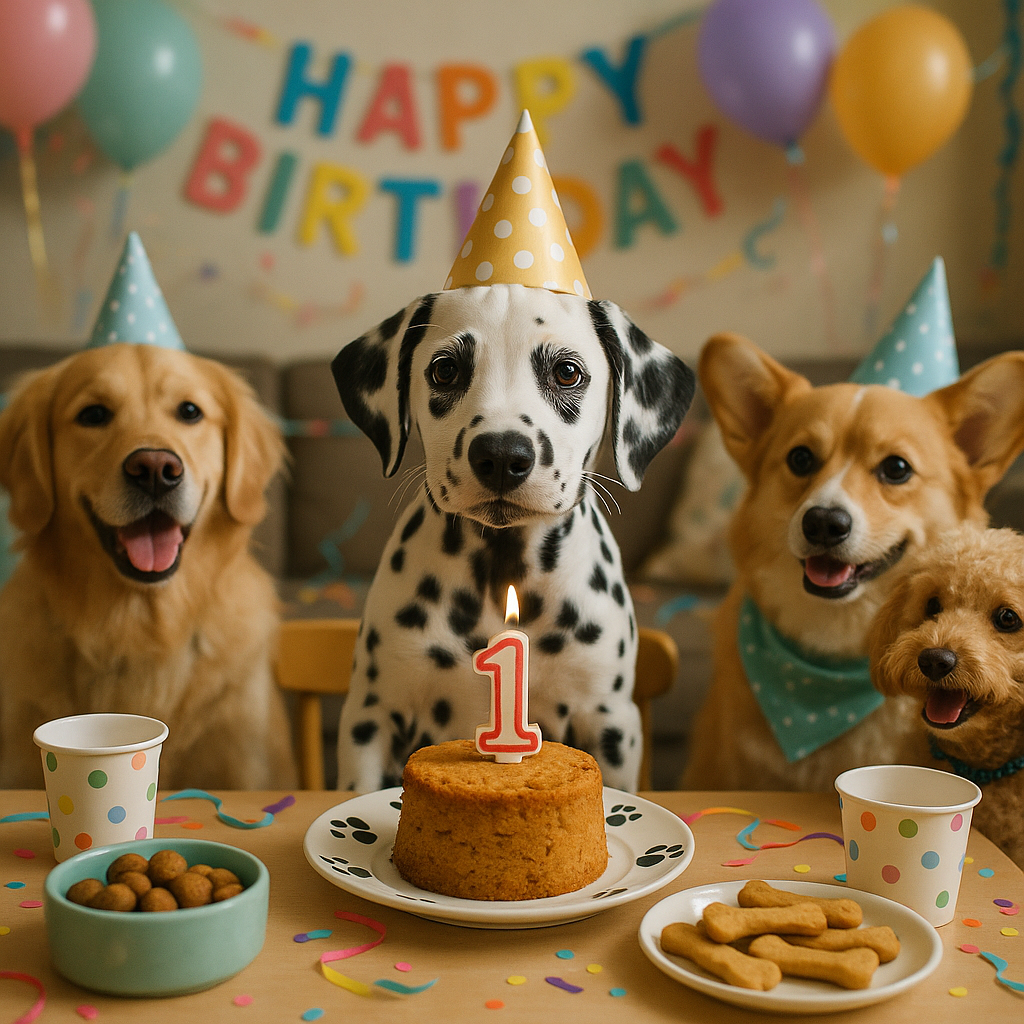

In [ ]:
image = Image.open(img_path)
image